/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


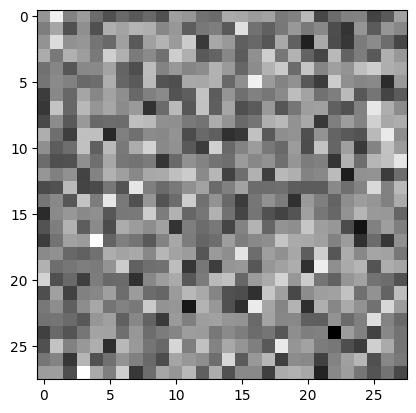

In [40]:
#this is deep learning project using gan 
#thsi is human face generator
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense,Reshape,Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist
#load dataset
(x_train,_),(_,_) = mnist.load_data()
#narmalize
x_train  = x_train /127.5 - 1.0
#reshape
x_train = np.expand_dims(x_train,axis=1)
#parameters
noise_dim = 100
batch_size = 32
epochs = 100
#generator
generator = Sequential([
Dense(256,input_dim=noise_dim),
LeakyReLU(0.2),
BatchNormalization(),

Dense(512),
LeakyReLU(0.2),
BatchNormalization(),

Dense(1024),
LeakyReLU(0.2),
BatchNormalization(),

Dense(28*28*1,activation='tanh'),
Reshape((28,28,1))

])
#discriminator
discriminator = Sequential([
Flatten(input_shape=(28,28,1)),
Dense(512),
LeakyReLU(0.2),
Dropout(0.3),

Dense(256),
LeakyReLU(0.2),
Dropout(0.3),

    

Dense(1,activation='sigmoid')
])
discriminator.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)
#GAN
discriminator.trainable = False
gan = Sequential([
generator,
discriminator
])
gan.compile(
optimizer='adam',
loss='binary_crossentropy'
)
#training
for epoch in range(epochs):
     idx = np.random.randint(0,
     x_train.shape[0],batch_size)
     real_images = x_train[idx]
     noise = np.random.normal(0,1,
(batch_size,noise_dim))

     fake_images = generator.predict(noise,verbose=0)

     real_labels = np.ones((batch_size,1))
     fake_labels = np.zeros((batch_size,1))

     d_loss_real = discriminator.train_on_batch(real_images,real_labels)
     d_loss_fake = discriminator.train_on_batch(fake_images,fake_labels)

#train generator
noise = np.random.normal(0,1,
(batch_size,noise_dim))

misleading_labels = np.ones((batch_size,1))
g_loss = gan.train_on_batch(noise,misleading_labels)

#print progress
if epoch % 100 ==0:
    print(f"epoch{epoch}")
    print(f"D loss real:{d_loss_real[0]}")# generate image
    noise = np.random.normal(0, 1, (5, noise_dim))

generated_images = generator.predict(noise)

#generator image
# generate image
noise = np.random.normal(0, 1, (5, noise_dim))

generated_images = generator.predict(noise)

# show image
for i in range(5):
     plt.imshow(generated_images[i].reshape(28,28), cmap='gray')
plt.show()

In [6]:
#this is ANN project
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#dataSet
data = {
    "experience":[1,2,3,4,5,6,7,8,9,10],
    "education":[1,1,2,2,3,3,4,4,5,5],
    "age":[22,24,26,28,30,32,34,36,38,40],
    "hours":[35,36,38,40,42,45,46,48,50,52],
    "skill_score":[40,45,50,55,60,70,75,80,90,95],
    "salary":[0,0,0,0,1,1,1,1,1,1]
    
}
df = pd.DataFrame(data)
#input/output
x = df.drop("salary",axis=1)
y = df["salary"]
#train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
#scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
#create model brain
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128,activation='relu',input_shape=(5,)),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64,activation='relu'),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32,activation='relu'),

    tf.keras.layers.Dense(1,activation='sigmoid')
])
#compile
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = 'binary_crossentropy',
    metrics=['accuracy']
)
#callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)
#train
history = model.fit(x_train,y_train,
validation_data=(x_test,y_test),
                   epochs=10,
                   callbacks=[early_stop,reduce_lr])

#evaluate 
loss,accuracy = model.evaluate(x_test,y_test)
print("loss:",loss)
print("accuracy:",accuracy)
#prediction
sample = np.array([[5,3,29,40,65]])
sample = scaler.transform(sample)
prediction = model.predict(sample)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6751 - val_accuracy: 1.0000 - val_loss: 0.6115 - learning_rate: 0.0010
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6250 - loss: 0.5048 - val_accuracy: 1.0000 - val_loss: 0.6079 - learning_rate: 0.0010
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5000 - loss: 0.9467 - val_accuracy: 1.0000 - val_loss: 0.6064 - learning_rate: 0.0010
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7500 - loss: 0.5049 - val_accuracy: 1.0000 - val_loss: 0.6031 - learning_rate: 0.0010
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7500 - loss: 0.4897 - val_accuracy: 1.0000 - val_loss: 0.5979 - learning_rate: 0.0010
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7500 - loss: 0.5245 - val_accuracy: 1.0000 - val_loss: 0.5911 - learning_rate: 0.0010
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7500 - loss: 0.5341 - val_accuracy: 1.0000 - val_loss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.2376 - val_loss: 0.7362 - learning_rate: 0.0010
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.2155 - val_loss: 0.6809 - learning_rate: 0.0010
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.1994 - val_loss: 0.6240 - learning_rate: 0.0010
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.1774 - val_loss: 0.5675 - learning_rate: 0.0010
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.1593 - val_loss: 0.5098 - learning_rate: 0.0010
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.1455 - val_loss: 0.4496 - learning_rate: 0.0010
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.1259 - val_loss: 0.3875 - learning_rate: 0.0010
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.1005 - val_loss: 0.3237 - learning_rate: 0.0010
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0848 - val_loss: 0.2589 - learning_rate: 0.0010
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10

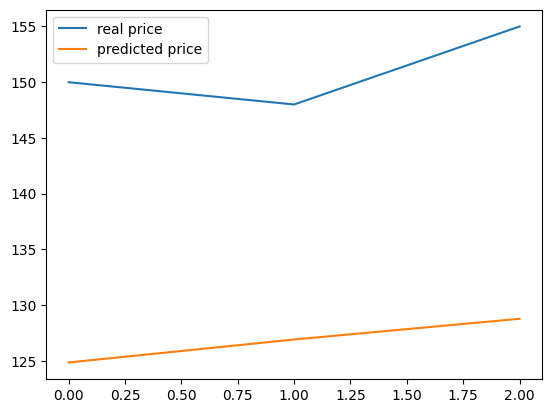

In [9]:
#this is stock market prediction using LSTM
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
#data
data = {
    "price":[
        100,102,104,103,105,107,110,115,117,120,125,130,128,132,135,140,145,150,148,155
    ]
}
df = pd.DataFrame(data)
#scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
#create Sequence
x = []
y = []
sequence_length = 5
for i in range(sequence_length,len(scaled_data)):
    x.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

x = np.array(x)
y = np.array(y)
#train test split
split = int(len(x)*0.8)

x_train = x[:split]
x_test = x[split:]

y_train = y[:split]
y_test = y[split:]

#model create brain
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64,
return_sequences=True,
input_shape=(x_train.shape[1],1)),
    
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1)
    
])
#compile
model.compile(
    optimizer='adam',
    loss='mse'
)
#callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)
# train
history = model.fit(
    x_train,y_train,
    validation_data=(x_test,y_test),
    epochs=10,
    callbacks=[early_stop,reduce_lr]
)
#predict
predictions = model.predict(x_test)
#inverse scaling
predictions = scaler.inverse_transform(predictions)

y_test_real = scaler.inverse_transform(y_test)
#plt
plt.plot(y_test_real,label="real price")
plt.plot(predictions,label="predicted price")
plt.legend()
plt.show()
